In [2]:
import pandas as pd
#data set load
import seaborn as sns
#Python data visualization library
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv(r"C:\Users\nihal\Downloads\cleaned_data.csv")

In [4]:

# Display basic info and the first few rows
display(df.info())
display(df.head())

# Rename columns for easier access during visualization
df.columns = [
    'Timestamp',
    'Age', 'Marital_Status', 'Age_At_Marriage', 'Family_Type', 'Primary_Education',
    'Highest_Education', 'Current_Status', 'Reason_Discontinuing_Studies', 
    'Preferred_Field', 'Wish_To_Work', 'Job_Type', 'Attended_Training', 
    'Interested_In_Job_Training', 'Interested_Skills', 'Biggest_Obstacle', 
    'Opportunity_After_Marriage', 'Family_Support', 'Home_Based_Work_Preference', 
    'Right_To_Opinion', 'Govt_Skill_Training_Interest', 'Govt_Schemes_Awareness', 
    'Willing_To_Participate', 'Biggest_Difficulty', 'Support_Needed', 'Confidence_Factors'
]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 26 columns):
 #   Column                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                              --------------  ----- 
 0   Timestamp                                                                                                           85 non-null     object
 1   1.Your age:                                                                                                         84 non-null     object
 2   2.Marital status:                                                                                                   82 non-null     object
 3   3.(If married) Age at the time of marriage:                                                                         79 non-null     object
 4   4.Family type:              

None

,Timestamp,1.Your age:,2.Marital status:,3.(If married) Age at the time of marriage:,4.Family type:,5.Do you have primary education?,6.Highest level of education completed:,7.Current status:,8.Main reason for discontinuing studies:,9.Which field of study do you prefer?,...,"16.After marriage, were you given the opportunity to continue your studies or work?",17.Does your family / husband support you in continuing education or working?,18.Do you think home-based work is more suitable for women?,19.Do you have the right to express your opinion in decisions related to your education/work?,20.Are you interested in participating in skill training programs organized by the government or college?,21.Are you aware of government education / employment schemes for women?,22.Are you willing to participate in such schemes?,"23.In your opinion, what is the biggest difficulty women face in your area in continuing education or employment?\n",24.What kind of support is needed to improve women’s education and employment?,"25.In your opinion, what factors help increase self-confidence among young women?"
0,2026/02/26 1:56:17 PM GMT+5:30,39,Married,Above 25,Nuclear Family,Yes,Secondary,Unemployed,Financial difficulty,Science,...,No,Yes,Not Sure,Sometimes,No,No,Not Ready,NaN,NaN,NaN
1,2026/02/26 1:56:48 PM GMT+5:30,33–35,Married,18–21,Nuclear Family,Yes,Secondary,Unemployed,Marriage,NaN,...,No,No,No,No,No,No,Not Ready,NaN,NaN,NaN
2,2026/02/26 1:56:58 PM GMT+5:30,52,Married,18–21,Nuclear Family,Yes,Primary,Homemaker,Financial difficulty,Nothing,...,No,No,Yes,Sometimes,Yes,No,Ready,Finance,Finance,Counselling
3,2026/02/26 1:57:43 PM GMT+5:30,56,Married,Below 18,Nuclear Family,Yes,Secondary,Homemaker,Financial difficulty,Tailoring,...,No,Yes,Yes,Sometimes,Yes,No,Ready,NaN,NaN,NaN
4,2026/02/26 1:58:15 PM GMT+5:30,44,Married,18–21,Nuclear Family,Yes,Higher Secondary,Homemaker,Marriage,Vocational training,...,Yes,No,Yes,Sometimes,Yes,No,Ready,Responsibility matters,NaN,NaN


In [5]:
df["Age"].unique()

array(['39', '33–35', '52', '56', '44', '28–32', '45', '40', '37', '49',
       '23–27', '18–22', '38', '47', '48', '42', '46', '36', '43', nan],
      dtype=object)

In [6]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [7]:
bins = [17,22,27,32,37,42,47,52,100]
labels = ['18-22','23-27','28-32','33-37','38-42','43-47','48-52','53+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

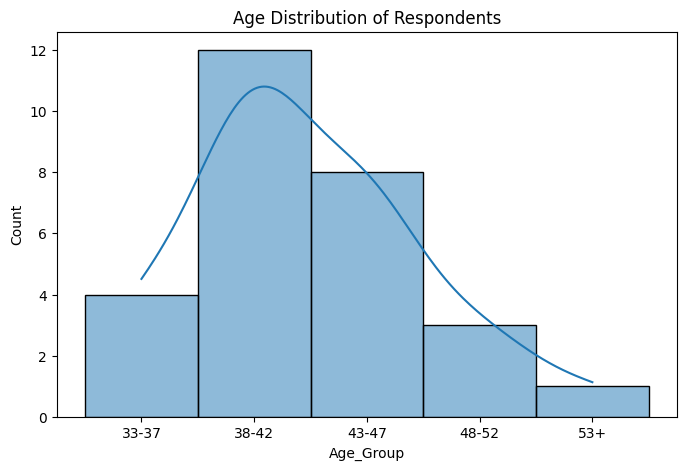

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age_Group'], bins=10, kde=True)
plt.title("Age Distribution of Respondents")
plt.show()

C:\Users\nihal\AppData\Local\Temp\ipykernel_17652\1308567174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Highest_Education', order=df['Highest_Education'].value_counts().index, palette='viridis')


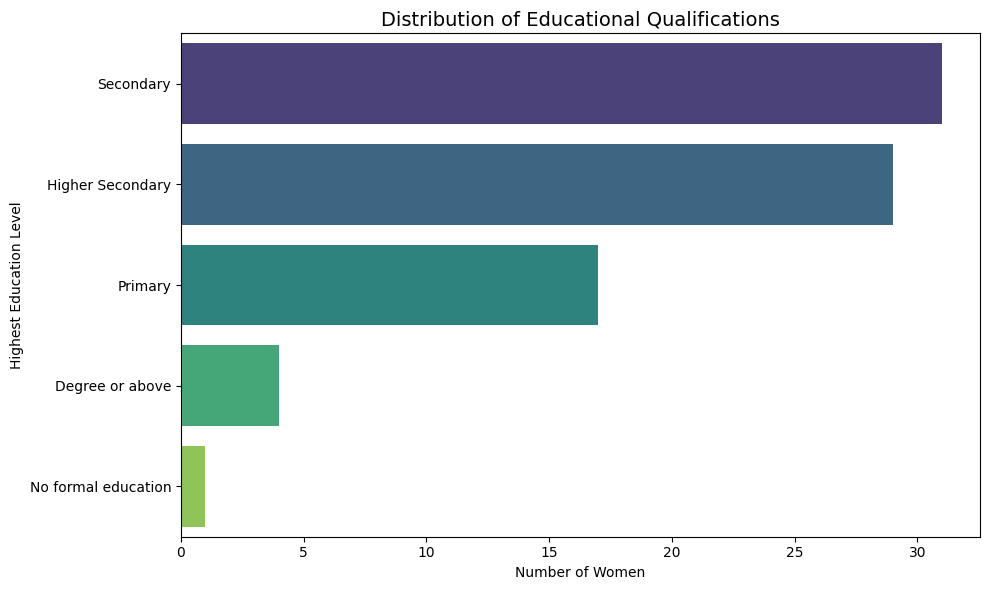

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Highest_Education', order=df['Highest_Education'].value_counts().index, palette='viridis')
plt.title('Distribution of Educational Qualifications', fontsize=14)
plt.xlabel('Number of Women')
plt.ylabel('Highest Education Level')
plt.tight_layout()
plt.show()


C:\Users\nihal\AppData\Local\Temp\ipykernel_17652\3006636157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Current_Status', order=df['Current_Status'].value_counts().index, palette='Set2')


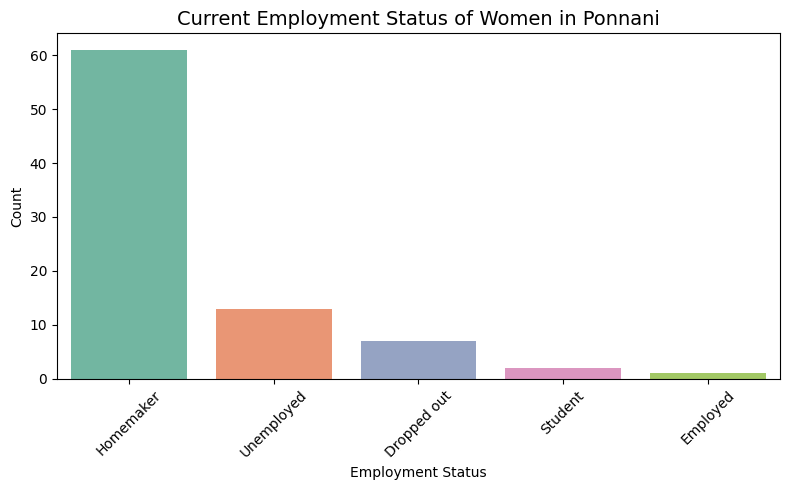

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Current_Status', order=df['Current_Status'].value_counts().index, palette='Set2')
plt.title('Current Employment Status of Women in Ponnani', fontsize=14)
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

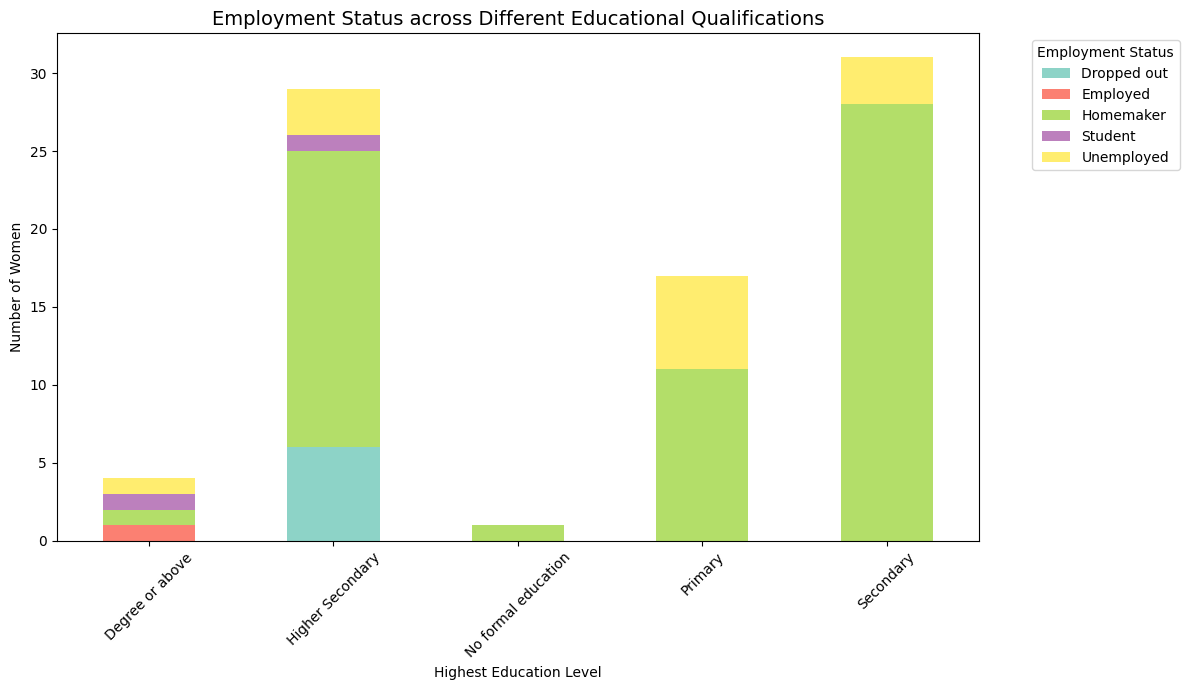

In [11]:
plt.figure(figsize=(8,5))
# Create a cross-tabulation of Education vs Employment Status
edu_emp_cross = pd.crosstab(df['Highest_Education'], df['Current_Status'])

# Plotting a stacked bar chart
edu_emp_cross.plot(kind='bar', stacked=True, colormap='Set3', figsize=(12, 7))
plt.title('Employment Status across Different Educational Qualifications', fontsize=14)
plt.xlabel('Highest Education Level')
plt.ylabel('Number of Women')
plt.xticks(rotation=45)
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\nihal\AppData\Local\Temp\ipykernel_17652\2439911006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=reasons.index, x=reasons.values, palette='magma')


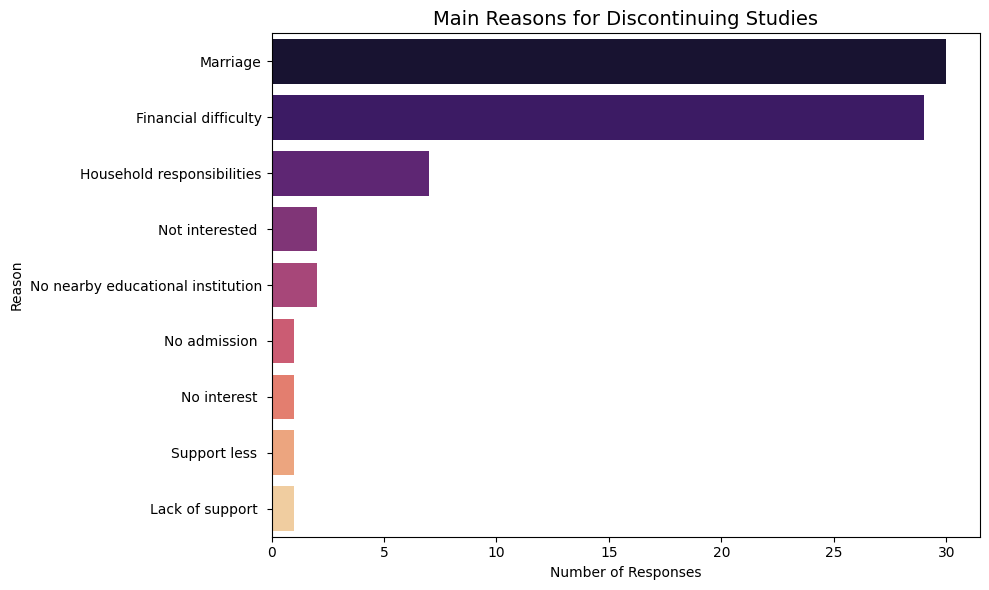

In [12]:
plt.figure(figsize=(10, 6))
reasons = df['Reason_Discontinuing_Studies'].dropna().value_counts()
sns.barplot(y=reasons.index, x=reasons.values, palette='magma')
plt.title('Main Reasons for Discontinuing Studies', fontsize=14)
plt.xlabel('Number of Responses')
plt.ylabel('Reason')
plt.tight_layout()
plt.show()


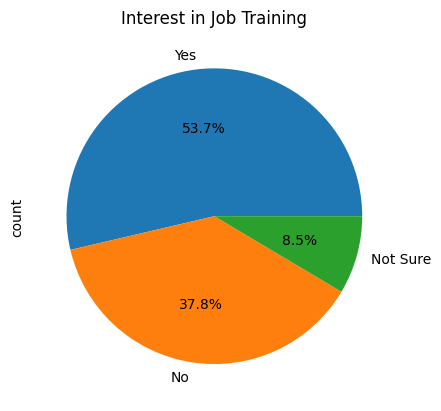

In [13]:
df['Interested_In_Job_Training'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Interest in Job Training")
plt.show()

C:\Users\nihal\AppData\Local\Temp\ipykernel_17652\2970307292.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=skills.index[:5], x=skills.values[:5], palette='coolwarm')


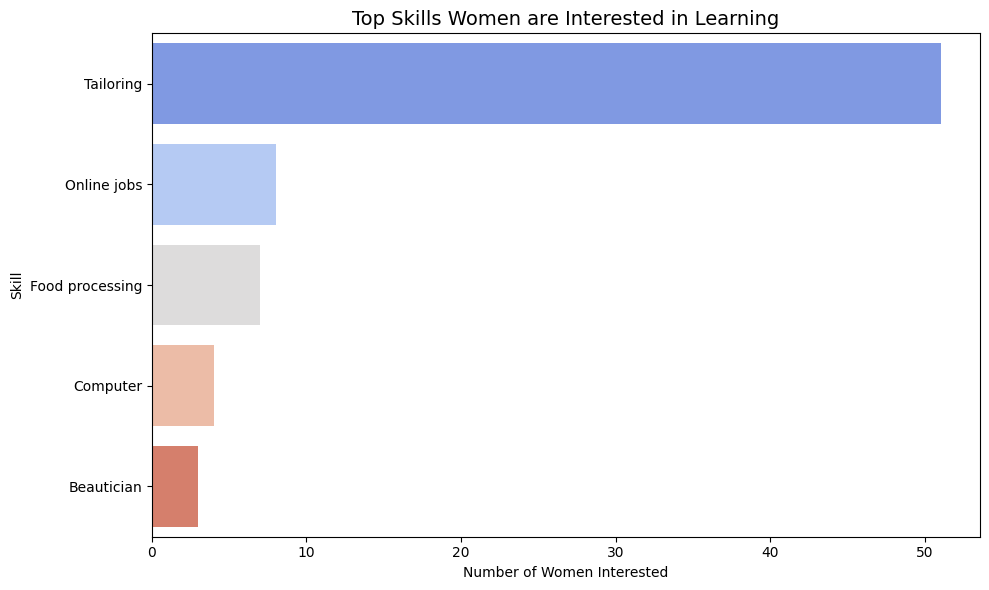

In [16]:
plt.figure(figsize=(10, 6))

skills = df['Interested_Skills'].dropna().str.split(';').explode().str.strip().value_counts()

# Interchange labels
skills = skills.rename({
    'Computer': 'Online jobs',
    'Online jobs': 'Beautician',
    'Beautician': 'Computer'
})

sns.barplot(y=skills.index[:5], x=skills.values[:5], palette='coolwarm')

plt.title('Top Skills Women are Interested in Learning', fontsize=14)
plt.xlabel('Number of Women Interested')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_11960\1342893571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=obstacles.index, x=obstacles.values, palette='cubehelix')


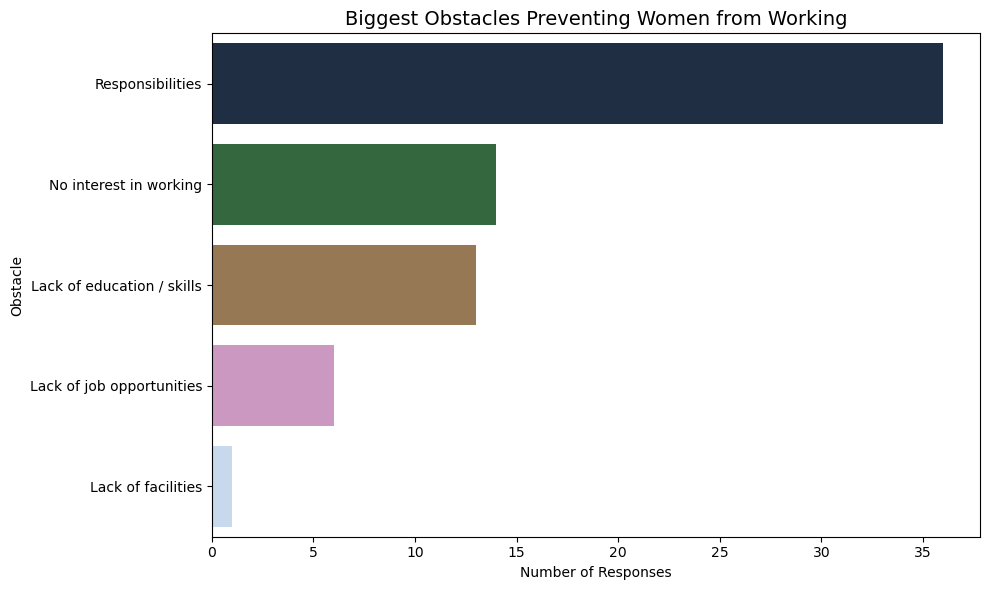

In [11]:
plt.figure(figsize=(10, 6))
obstacles = df['Biggest_Obstacle'].dropna().value_counts()
sns.barplot(y=obstacles.index, x=obstacles.values, palette='cubehelix')
plt.title('Biggest Obstacles Preventing Women from Working', fontsize=14)
plt.xlabel('Number of Responses')
plt.ylabel('Obstacle')
plt.tight_layout()
plt.show()


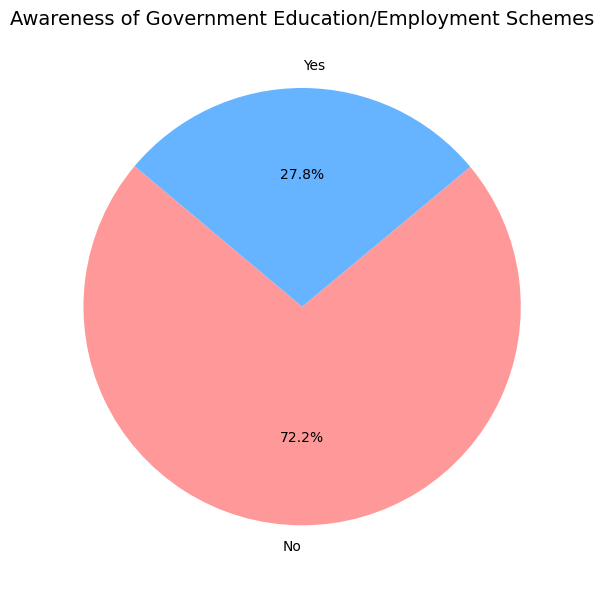

In [8]:
plt.figure(figsize=(6, 6))
schemes_awareness = df['Govt_Schemes_Awareness'].value_counts()
plt.pie(schemes_awareness, labels=schemes_awareness.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff', '#99ff99'])
plt.title('Awareness of Government Education/Employment Schemes', fontsize=14)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Scheme Awareness vs Training Interest')

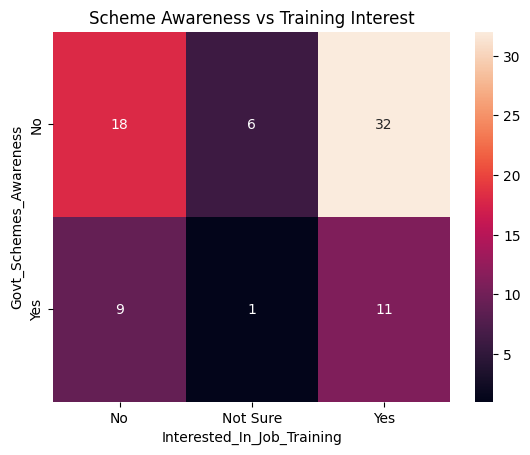

In [24]:
aware_train = pd.crosstab(df['Govt_Schemes_Awareness'], df['Interested_In_Job_Training'])

sns.heatmap(aware_train, annot=True)
plt.title("Scheme Awareness vs Training Interest")

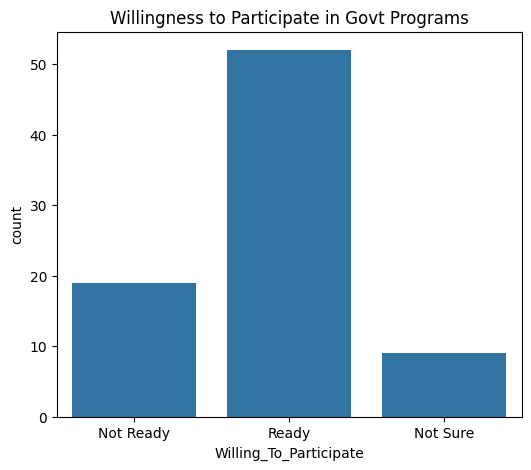

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(x='Willing_To_Participate', data=df)
plt.title("Willingness to Participate in Govt Programs")
plt.show()

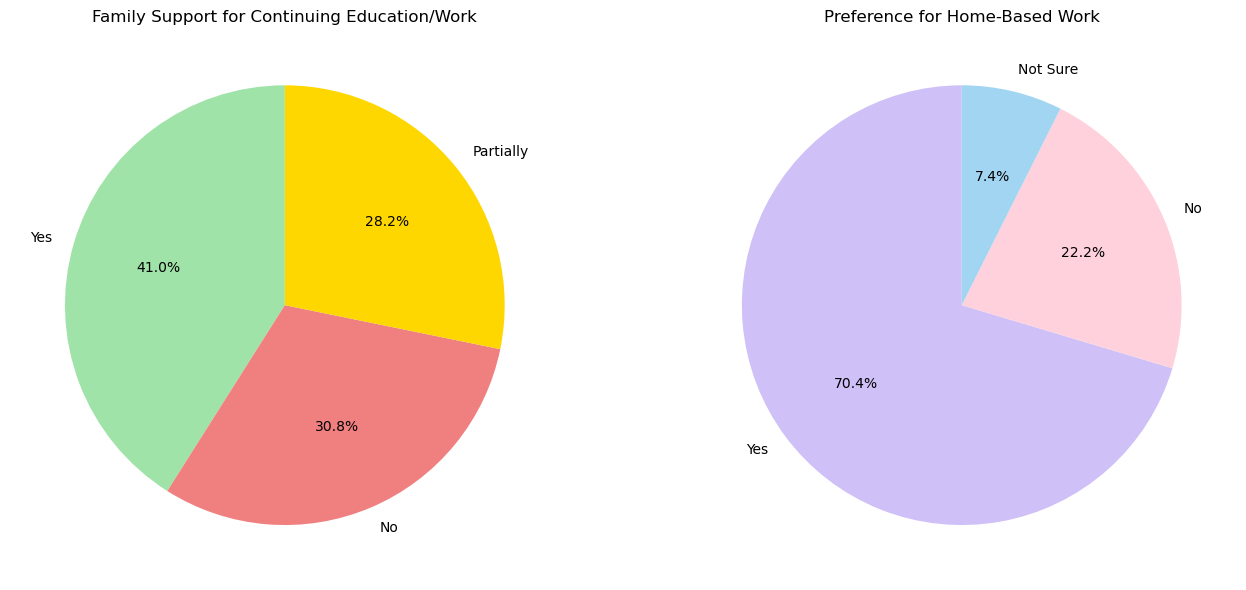

In [12]:
# Create a 1x2 subplot for Family Support and Home-Based Work Preference
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Family Support Pie Chart
family_support = df['Family_Support'].value_counts()
axes[0].pie(family_support, labels=family_support.index, autopct='%1.1f%%', startangle=90, colors=['#a0e3a8','#f08080', '#ffd700'])
axes[0].set_title('Family Support for Continuing Education/Work')

# Home-based Work Preference Pie Chart
home_work = df['Home_Based_Work_Preference'].value_counts()
axes[1].pie(home_work, labels=home_work.index, autopct='%1.1f%%', startangle=90, colors=['#cfc0f7','#ffd1dc', '#a2d5f2'])
axes[1].set_title('Preference for Home-Based Work')

plt.tight_layout()
plt.show()


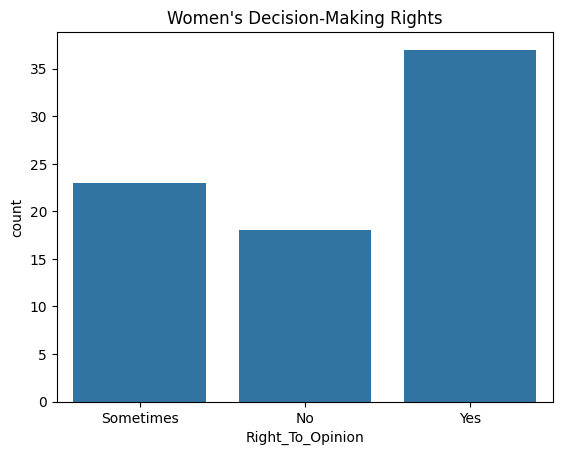

In [25]:
sns.countplot(x='Right_To_Opinion', data=df)
plt.title("Women's Decision-Making Rights")
plt.show()


Text(0.5, 1.0, 'Family Support vs Wish to Work')

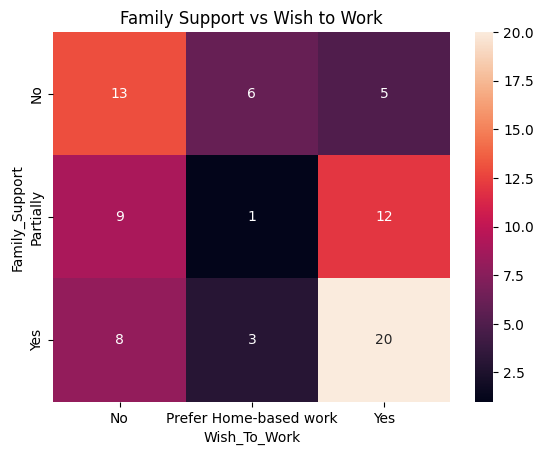

In [23]:
support_work = pd.crosstab(df['Family_Support'], df['Wish_To_Work'])

sns.heatmap(support_work, annot=True)
plt.title("Family Support vs Wish to Work")

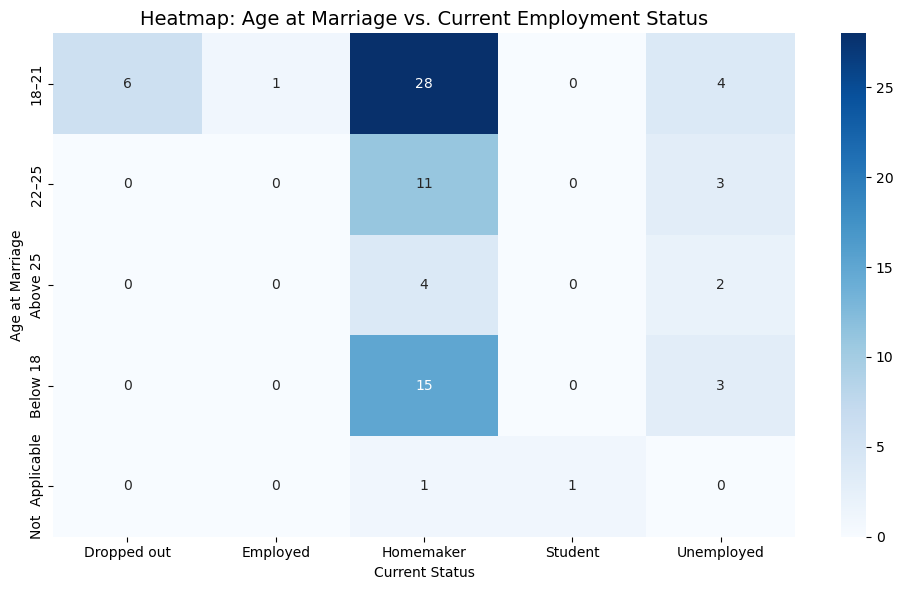

In [16]:
plt.figure(figsize=(10, 6))
# Create a cross-tabulation of Age at Marriage vs Current Status
marriage_emp_cross = pd.crosstab(df['Age_At_Marriage'], df['Current_Status'])

sns.heatmap(marriage_emp_cross, annot=True, cmap='Blues', fmt='d')
plt.title('Heatmap: Age at Marriage vs. Current Employment Status', fontsize=14)
plt.xlabel('Current Status')
plt.ylabel('Age at Marriage')
plt.tight_layout()
plt.show()


In [13]:
# Create a quick summary of key percentages
total_respondents = len(df)
summary_stats = {
    'Unemployed or Homemaker (%)': round(((df['Current_Status'] == 'Unemployed').sum() + (df['Current_Status'] == 'Homemaker').sum()) / total_respondents * 100, 2),
    'Interested in Job Training (%)': round((df['Interested_In_Job_Training'] == 'Yes').sum() / total_respondents * 100, 2),
    'Lack Awareness of Govt Schemes (%)': round((df['Govt_Schemes_Awareness'] == 'No').sum() / total_respondents * 100, 2)
}

summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Percentage'])
display(summary_df)

# Save the summary to a CSV if needed for the final report
summary_df.to_csv("key_findings_summary.csv", index=False)
print("Saved key findings summary to 'key_findings_summary.csv'")


,Metric,Percentage
0,Unemployed or Homemaker (%),88.10
1,Interested in Job Training (%),52.38
2,Lack Awareness of Govt Schemes (%),67.86


Saved key findings summary to 'key_findings_summary.csv'


In [15]:
print("--- EXACT FIGURES FOR YOUR SURVEY REPORT ---")
print("\n1. Education & Employment Gap:")
employed_pct = (df['Current_Status'] == 'Employed').mean() * 100
unemployed_hm_pct = ((df['Current_Status'] == 'Unemployed') | (df['Current_Status'] == 'Homemaker')).mean() * 100
print(f"Only {employed_pct:.1f}% of respondents are currently employed, while {unemployed_hm_pct:.1f}% are unemployed or homemakers.")

print("\n2. Reasons for Discontinuing Education:")
top_reason = df['Reason_Discontinuing_Studies'].value_counts().index[0]
top_reason_pct = df['Reason_Discontinuing_Studies'].value_counts(normalize=True).iloc[0] * 100
print(f"The primary reason for discontinuing education was '{top_reason}', accounting for {top_reason_pct:.1f}% of specific responses.")

print("\n3. Awareness of Government Schemes:")
unaware_pct = (df['Govt_Schemes_Awareness'] == 'No').mean() * 100
print(f"A massive {unaware_pct:.1f}% of women are NOT aware of government welfare schemes available to them.")

print("\n4. Interest in Skill Training:")
training_interest = (df['Govt_Skill_Training_Interest'] == 'Ready').mean() * 100
print(f"{training_interest:.1f}% of respondents are ready and interested in participating in skill training if provided by the government or college.")


--- EXACT FIGURES FOR YOUR SURVEY REPORT ---

1. Education & Employment Gap:
Only 1.2% of respondents are currently employed, while 88.1% are unemployed or homemakers.

2. Reasons for Discontinuing Education:
The primary reason for discontinuing education was 'Marriage', accounting for 40.5% of specific responses.

3. Awareness of Government Schemes:
A massive 67.9% of women are NOT aware of government welfare schemes available to them.

4. Interest in Skill Training:
0.0% of respondents are ready and interested in participating in skill training if provided by the government or college.


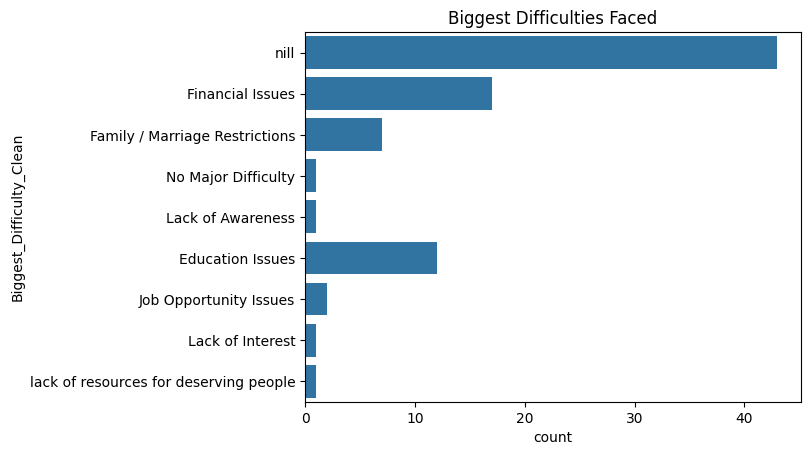

In [74]:
sns.countplot(y='Biggest_Difficulty_Clean', data=df)
plt.title("Biggest Difficulties Faced")
plt.show()

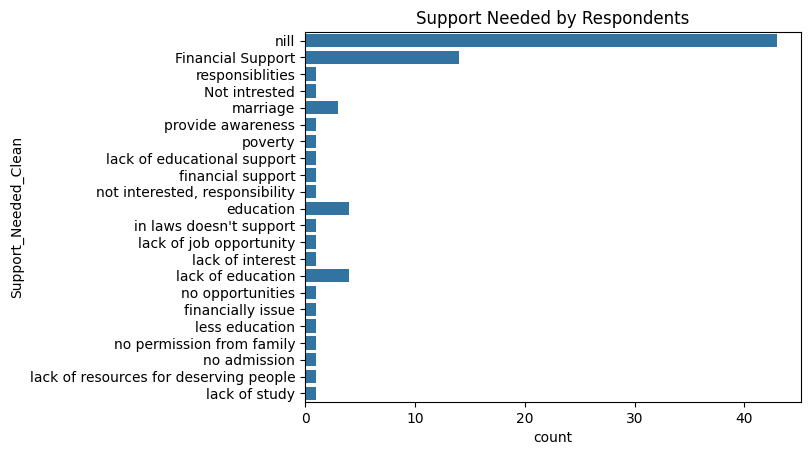

In [81]:
sns.countplot(y='Support_Needed_Clean', data=df)
plt.title("Support Needed by Respondents")
plt.show()

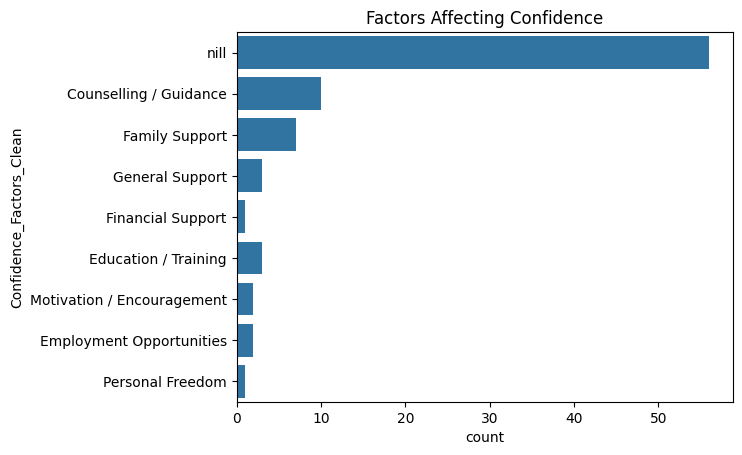

In [79]:
sns.countplot(y='Confidence_Factors_Clean', data=df)
plt.title("Factors Affecting Confidence")
plt.show()

In [36]:
df['Biggest_Difficulty'] = df['Biggest_Difficulty'].str.lower().str.strip()

In [39]:
difficulty_map = {

    # Financial problems
    'finance': 'Financial Issues',
    'financial': 'Financial Issues',
    'financial problems': 'Financial Issues',
    'financial support': 'Financial Issues',
    'financial issues': 'Financial Issues',
    'financially': 'Financial Issues',
    'financially issue': 'Financial Issues',
    'financial difficulties': 'Financial Issues',
    'finance, no help': 'Financial Issues',
    'poverty': 'Financial Issues',

    # Education related
    'education': 'Education Issues',
    'lack of education': 'Education Issues',
    'less education': 'Education Issues',
    'no admission': 'Education Issues',
    'lack of study': 'Education Issues',
    'lack of educational support': 'Education Issues',

    # Marriage / family restriction
    'marriage': 'Family / Marriage Restrictions',
    'responsibility matters': 'Family / Marriage Restrictions',
    'not interested, responsibility': 'Family / Marriage Restrictions',
    'no permission from family': 'Family / Marriage Restrictions',
    "in laws doesn't support": 'Family / Marriage Restrictions',

    # Job opportunities
    'lack of job opportunity': 'Job Opportunity Issues',
    'no opportunities': 'Job Opportunity Issues',

    # Awareness
    'provide awareness': 'Lack of Awareness',

    # Personal interest
    'lack of interest': 'Lack of Interest',

    # No difficulty
    'no': 'No Major Difficulty'
}

In [73]:
df['Biggest_Difficulty_Clean'] = df['Biggest_Difficulty'].replace(difficulty_map)
df['Biggest_Difficulty_Clean'] = df['Biggest_Difficulty_Clean'].fillna('nill')

In [60]:
df['Support_Needed'] = df['Biggest_Difficulty'].str.lower().str.strip()

In [66]:
support_map = {

    # Financial support
    'finance': 'Financial Support',
    'financial': 'Financial Support',
    'financial problem': 'Financial Support',
    'financial problems': 'Financial Support',
    'financial issues': 'Financial Support',
    'financial difficult': 'Financial Support',
    'financially': 'Financial Support',
    'financial difficulties': 'Financial Support',
    'finance, no help' : 'Financial Support',
    'responsibility matters': 'responsiblities',
    # Job opportunities
    'job': 'Job Opportunities',
    'job opportunities': 'Job Opportunities',
    'more job opportunities': 'Job Opportunities',
    'no job opportunity': 'Job Opportunities',
    'provide more job opportunity': 'Job Opportunities',
    'opportunities': 'Job Opportunities',

    # Training / education
    'training': 'Training / Skill Development',
    'training and education': 'Training / Skill Development',

    # Family support
    'family support': 'Family Support',

    # Awareness
    'awareness': 'Awareness Programs',

    # Work from home
    'work from home': 'Work From Home Opportunities',

    # Fair opportunities
    'give chances': 'Equal Opportunities',
    'give deserving people': 'Equal Opportunities',
    'no' : 'Not intrested'
}

In [80]:
df['Support_Needed_Clean'] = df['Support_Needed'].replace(support_map)
df['Support_Needed_Clean'] = df['Support_Needed_Clean'].fillna('nill')

In [75]:
df['Confidence_Factors'].unique()

array([nan, 'Counselling ', 'Support of family',
       'Support of family members ', 'Family support', 'Support ',
       'Poverty ', 'Education ', 'Family support ', 'Support',
       'Motivation', 'Counciling', 'Councilling', 'Motivation class',
       'Job', 'Counciling ', 'Freedom', 'Training, class'], dtype=object)

In [76]:
df['Confidence_Factors'] = df['Confidence_Factors'].str.lower().str.strip()

In [77]:
confidence_map = {

    # Counselling / guidance
    'counselling': 'Counselling / Guidance',
    'counciling': 'Counselling / Guidance',
    'councilling': 'Counselling / Guidance',

    # Family support
    'support of family': 'Family Support',
    'support of family members': 'Family Support',
    'family support': 'Family Support',

    # General support
    'support': 'General Support',

    # Financial hardship
    'poverty': 'Financial Support',

    # Education / training
    'education': 'Education / Training',
    'training, class': 'Education / Training',

    # Motivation
    'motivation': 'Motivation / Encouragement',
    'motivation class': 'Motivation / Encouragement',

    # Employment
    'job': 'Employment Opportunities',

    # Personal freedom
    'freedom': 'Personal Freedom'
}

In [78]:
df['Confidence_Factors_Clean'] = df['Confidence_Factors'].replace(confidence_map)
df['Confidence_Factors_Clean'] = df['Confidence_Factors_Clean'].fillna('nill')

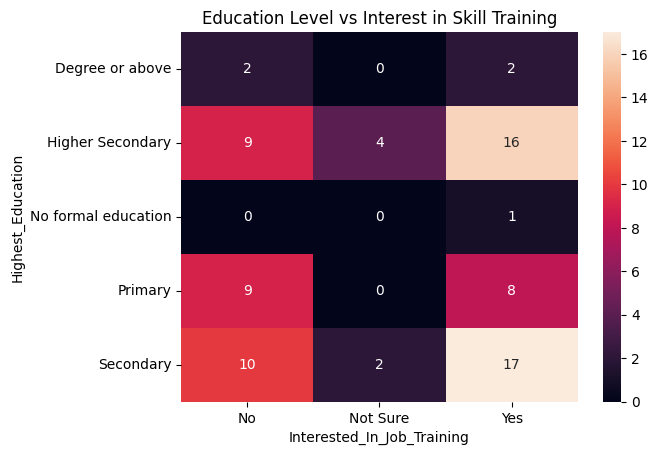

In [84]:
edu_training = pd.crosstab(df['Highest_Education'], df['Interested_In_Job_Training'])

sns.heatmap(edu_training, annot=True, fmt='d')

plt.title("Education Level vs Interest in Skill Training")
plt.show()